# 00 - Auditoría y EDA de los datos

## 1. Dependencias y entorno

In [55]:
#Instalar dependencias
%pip install pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [56]:
#Librerías
from pathlib import Path
import hashlib
import platform
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 120)
SEMILLA = 20260724
np.random.seed(SEMILLA)

In [57]:
#Versiones
versiones = pd.DataFrame([
    {'componente': 'Python', 'version': sys.version.split()[0]},
    {'componente': 'Sistema', 'version': platform.platform()},
    {'componente': 'Pandas', 'version': pd.__version__},
    {'componente': 'NumPy', 'version': np.__version__},
    {'componente': 'Matplotlib', 'version': plt.matplotlib.__version__},
])

display(versiones)

,componente,version
0,Python,3.14.3
1,Sistema,macOS-26.5.2-arm64-arm-64bit-Mach-O
2,Pandas,3.0.3
3,NumPy,2.5.1
4,Matplotlib,3.11.1


## 2. Ubicación y contrato de archivos

In [86]:
#Datasets y rutas
ruta_proyecto = Path.cwd().resolve().parent
ruta_datasets = ruta_proyecto / 'Datasets'

archivos = {
    'perfiles': ruta_datasets / 'perfil_integral_usuario.csv',
    'transacciones': ruta_datasets / 'transacciones_contextualizadas.csv',
    'trayectorias': ruta_datasets / 'trayectorias_financieras.csv',
    'decisiones': ruta_datasets / 'decisiones_recomendaciones.csv',
}

print(f'Proyecto: {ruta_proyecto}')
print(f'Datasets: {ruta_datasets}')

Proyecto: /Users/jeis/Documents/esc/Proyectos/hackaton
Datasets: /Users/jeis/Documents/esc/Proyectos/hackaton/Datasets


In [59]:
#Verificar datasets
estado_archivos = pd.DataFrame([
    {
        'dataset': nombre,
        'archivo': ruta.name,
        'existe': ruta.exists(),
        'tamano_mb': round(ruta.stat().st_size / 1024 ** 2, 3) if ruta.exists() else 0,
    }
    for nombre, ruta in archivos.items()
])

archivos_ok = bool(estado_archivos['existe'].all())
display(estado_archivos)
assert archivos_ok, 'Falta uno o más datasets obligatorios'

,dataset,archivo,existe,tamano_mb
0,perfiles,perfil_integral_usuario.csv,True,0.191
1,transacciones,transacciones_contextualizadas.csv,True,7.284
2,trayectorias,trayectorias_financieras.csv,True,0.519
3,decisiones,decisiones_recomendaciones.csv,True,0.652


## 3. Carga reproducible

In [60]:
#Cargar datasets
datos = {nombre: pd.read_csv(ruta, low_memory=False) for nombre, ruta in archivos.items()}
datos_crudos = {
    nombre: pd.read_csv(ruta, dtype=str, keep_default_na=False, low_memory=False)
    for nombre, ruta in archivos.items()
}

resumen_carga = pd.DataFrame([
    {
        'dataset': nombre,
        'filas': len(tabla),
        'columnas': tabla.shape[1],
        'memoria_mb': round(tabla.memory_usage(deep=True).sum() / 1024 ** 2, 3),
    }
    for nombre, tabla in datos.items()
])

display(resumen_carga)

,dataset,filas,columnas,memoria_mb
0,perfiles,200,43,0.495
1,transacciones,19077,33,32.407
2,trayectorias,600,51,1.161
3,decisiones,600,28,1.425


In [87]:
#Validar condición del dataset
filas_esperadas = {
    'perfiles': 200,
    'transacciones': 19077,
    'trayectorias': 600,
    'decisiones': 600,
}

comparacion_filas = pd.DataFrame([
    {
        'dataset': nombre,
        'esperadas': esperadas,
        'observadas': len(datos[nombre]),
        'coincide': len(datos[nombre]) == esperadas,
    }
    for nombre, esperadas in filas_esperadas.items()
])

filas_ok = bool(comparacion_filas['coincide'].all())
display(comparacion_filas)
assert filas_ok, 'Las cantidades de filas no corresponden'

,dataset,esperadas,observadas,coincide
0,perfiles,200,200,True
1,transacciones,19077,19077,True
2,trayectorias,600,600,True
3,decisiones,600,600,True


## 4. Esquemas y campos obligatorios

In [62]:
#Revisar esquemas y campos
columnas_obligatorias = {
    'perfiles': ['perfil_id', 'descripcion_visible', 'estado_alcance_mvp', 'actividad_1_codigo_cuoc', 'actividad_1_ocupacion_cuoc', 'hobby_1', 'particion', 'version_esquema', 'huella_registro'],
    'transacciones': ['transaccion_id', 'perfil_id', 'fecha', 'descripcion_original', 'descripcion_normalizada', 'valor', 'direccion', 'tipo_movimiento', 'categoria_principal', 'finalidad', 'nota_usuario', 'estado_clasificacion', 'estado_alcance_mvp', 'particion', 'version_esquema', 'huella_registro'],
    'trayectorias': ['ventana_id', 'perfil_id', 'estado_alcance_mvp', 'periodo_desde', 'periodo_hasta', 'transacciones_observadas', 'estado_trayectoria', 'particion', 'version_esquema', 'huella_registro'],
    'decisiones': ['decision_id', 'perfil_id', 'estado_alcance_mvp', 'ventana_id', 'estado_trayectoria', 'recomendacion_id', 'decision', 'particion', 'version_esquema', 'huella_registro'],
}

revision_esquema = []

for nombre, requeridas in columnas_obligatorias.items():
    faltantes = [columna for columna in requeridas if columna not in datos[nombre].columns]
    revision_esquema.append({
        'dataset': nombre,
        'columnas_observadas': datos[nombre].shape[1],
        'obligatorias': len(requeridas),
        'faltantes': ' | '.join(faltantes) if faltantes else 'ninguna',
        'estado': 'OK' if not faltantes else 'BLOQUEO',
    })

revision_esquema = pd.DataFrame(revision_esquema)
esquema_ok = bool(revision_esquema['estado'].eq('OK').all())
display(revision_esquema)
assert esquema_ok, 'Hay columnas obligatorias ausentes'

,dataset,columnas_observadas,obligatorias,faltantes,estado
0,perfiles,43,9,ninguna,OK
1,transacciones,33,16,ninguna,OK
2,trayectorias,51,10,ninguna,OK
3,decisiones,28,10,ninguna,OK


In [63]:
#Tipos
resumen_tipos = []

for nombre, tabla in datos.items():
    for tipo, cantidad in tabla.dtypes.astype(str).value_counts().items():
        resumen_tipos.append({'dataset': nombre, 'tipo_inferido': tipo, 'columnas': int(cantidad)})

display(pd.DataFrame(resumen_tipos))

,dataset,tipo_inferido,columnas
0,perfiles,str,34
1,perfiles,int64,5
2,perfiles,float64,4
3,transacciones,str,30
4,transacciones,int64,2
5,transacciones,float64,1
6,trayectorias,str,22
7,trayectorias,int64,21
8,trayectorias,float64,8
9,decisiones,str,28


## 5. Alcance cerrado del MVP

In [64]:
#Ocupaciones del MVP
perfiles = datos['perfiles']
ocupaciones = perfiles.groupby(['actividad_1_codigo_cuoc', 'actividad_1_ocupacion_cuoc'], dropna=False).size().reset_index(name='usuarios')
ocupaciones_ok = len(ocupaciones) == 10 and ocupaciones['usuarios'].eq(20).all()
display(ocupaciones.sort_values('actividad_1_codigo_cuoc').reset_index(drop=True))
assert ocupaciones_ok, 'Las diez ocupaciones no están balanceadas con veinte usuarios cada una'

,actividad_1_codigo_cuoc,actividad_1_ocupacion_cuoc,usuarios
0,22650,Nutricionistas dietistas,20
1,23300,Profesores de educación secundaria / Profesoras de educación secundaria,20
2,25120,Desarrolladores de software / Desarrolladoras de software,20
3,26521,Intérpretes musicales,20
4,26541,"Productores, directores y editores de cine, teatro y afines / Productoras, directoras y editoras de cine, teatro y a...",20
5,34210,Atletas y deportistas,20
6,51410,Peluqueros / Peluqueras,20
7,52230,"Vendedores y auxiliares de venta en tiendas, almacenes y afines / Vendedoras y auxiliares de venta en tiendas, almac...",20
8,61131,"Agricultores de huertas, invernaderos, viveros y jardines / Agricultoras de huertas, invernaderos, viveros y jardines",20
9,96211,"Mandaderos, maleteros y repartidores / Mandaderas, maleteras y repartidoras",20


In [65]:
#Hobbies del MVP
hobbies = pd.concat([perfiles['hobby_1'], perfiles['hobby_2']], ignore_index=True).dropna()
hobbies = hobbies[hobbies.astype(str).str.strip().ne('')]
conteo_hobbies = hobbies.value_counts().rename_axis('hobby').reset_index(name='usuarios')
hobbies_ok = len(conteo_hobbies) == 10
display(conteo_hobbies)
assert hobbies_ok, 'El catálogo de hobbies no contiene exactamente diez valores'

,hobby,usuarios
0,cocina_y_reposteria,37
1,turismo_y_viajes,35
2,pintura,34
3,fotografia_y_video,34
4,videojuegos_y_streaming,32
5,manualidades_y_artesanias,31
6,impresion_3d,31
7,jardineria_y_agricultura_urbana,31
8,ciclismo,28
9,musica,26


In [66]:
#Alcance
revision_alcance = pd.DataFrame([
    {
        'dataset': nombre,
        'valores': ' | '.join(sorted(tabla['estado_alcance_mvp'].dropna().astype(str).unique())),
        'dentro_del_mvp': int(tabla['estado_alcance_mvp'].eq('dentro_del_mvp').sum()),
        'total': len(tabla),
        'completo': bool(tabla['estado_alcance_mvp'].eq('dentro_del_mvp').all()),
    }
    for nombre, tabla in datos.items()
])

alcance_ok = bool(revision_alcance['completo'].all())
display(revision_alcance)
assert alcance_ok, 'Existe un registro de entrenamiento fuera del alcance cerrado'

,dataset,valores,dentro_del_mvp,total,completo
0,perfiles,dentro_del_mvp,200,200,True
1,transacciones,dentro_del_mvp,19077,19077,True
2,trayectorias,dentro_del_mvp,600,600,True
3,decisiones,dentro_del_mvp,600,600,True


## 6. Particiones sin fuga por usuario

In [88]:
#Validar códigos de la activiad
orden_particiones = ['train', 'validation', 'test']
tabla_particiones = pd.crosstab(perfiles['actividad_1_codigo_cuoc'], perfiles['particion']).reindex(columns=orden_particiones, fill_value=0)
esperado_particion = pd.Series({'train': 14, 'validation': 3, 'test': 3})
estratificacion_ok = bool(tabla_particiones.eq(esperado_particion).all().all())
display(tabla_particiones)
assert estratificacion_ok, 'La partición no está bien para cada ocupación'

particion,train,validation,test
actividad_1_codigo_cuoc,,,
22650,14,3,3
23300,14,3,3
25120,14,3,3
26521,14,3,3
26541,14,3,3
34210,14,3,3
51410,14,3,3
52230,14,3,3
61131,14,3,3


In [68]:
#Validar separación
perfiles_por_particion = {
    particion: set(perfiles.loc[perfiles['particion'].eq(particion), 'perfil_id'])
    for particion in orden_particiones
}

intersecciones = pd.DataFrame([
    {
        'comparacion': 'train vs validation',
        'perfiles_compartidos': len(perfiles_por_particion['train'] & perfiles_por_particion['validation']),
    },
    {
        'comparacion': 'train vs test',
        'perfiles_compartidos': len(perfiles_por_particion['train'] & perfiles_por_particion['test']),
    },
    {
        'comparacion': 'validation vs test',
        'perfiles_compartidos': len(perfiles_por_particion['validation'] & perfiles_por_particion['test']),
    },
])

separacion_ok = bool(intersecciones['perfiles_compartidos'].eq(0).all())
display(intersecciones)
assert separacion_ok, 'Un perfil aparece en más de una partición'

,comparacion,perfiles_compartidos
0,train vs validation,0
1,train vs test,0
2,validation vs test,0


## 7. Calidad, faltantes y duplicados

In [69]:
#Faltantes
revision_faltantes = []

for nombre, requeridas in columnas_obligatorias.items():
    tabla = datos[nombre]
    for columna in requeridas:
        if nombre == 'transacciones' and columna == 'nota_usuario':
            continue

        vacios = tabla[columna].isna() | tabla[columna].fillna('').astype(str).str.strip().eq('')
        revision_faltantes.append({'dataset': nombre, 'columna': columna, 'faltantes': int(vacios.sum())})

revision_faltantes = pd.DataFrame(revision_faltantes)
faltantes_obligatorios = revision_faltantes.loc[revision_faltantes['faltantes'].gt(0)]
display(faltantes_obligatorios if not faltantes_obligatorios.empty else pd.DataFrame([{'resultado': 'Sin faltantes en campos obligatorios'}]))

,resultado
0,Sin faltantes en campos obligatorios


In [70]:
#Opcionales
opcionales_perfil = ['actividad_2_familia', 'hobby_2', 'meta_declarada', 'responsabilidad_declarada']

faltantes_opcionales = pd.DataFrame([
    {
        'columna': columna,
        'faltantes': int((perfiles[columna].isna() | perfiles[columna].fillna('').astype(str).str.strip().eq('')).sum()),
        'porcentaje': round((perfiles[columna].isna() | perfiles[columna].fillna('').astype(str).str.strip().eq('')).mean() * 100, 2),
    }
    for columna in opcionales_perfil
])

display(faltantes_opcionales)

,columna,faltantes,porcentaje
0,actividad_2_familia,104,52.0
1,hobby_2,81,40.5
2,meta_declarada,75,37.5
3,responsabilidad_declarada,92,46.0


In [71]:
#Duplicados
identificadores = {
    'perfiles': 'perfil_id',
    'transacciones': 'transaccion_id',
    'trayectorias': 'ventana_id',
    'decisiones': 'decision_id',
}

revision_duplicados = pd.DataFrame([
    {
        'dataset': nombre,
        'id_duplicado': int(tabla[identificadores[nombre]].duplicated().sum()),
        'huella_duplicada': int(tabla['huella_registro'].duplicated().sum()),
        'fila_completa_duplicada': int(tabla.duplicated().sum()),
    }
    for nombre, tabla in datos.items()
])

duplicados_ok = bool(revision_duplicados.select_dtypes(include='number').eq(0).all().all())
display(revision_duplicados)
assert duplicados_ok, 'Se encontraron identificadores, huellas o filas duplicadas'

,dataset,id_duplicado,huella_duplicada,fila_completa_duplicada
0,perfiles,0,0,0
1,transacciones,0,0,0
2,trayectorias,0,0,0
3,decisiones,0,0,0


In [72]:
#Validar valores
transacciones = datos['transacciones']
valores = pd.to_numeric(transacciones['valor'], errors='coerce')
fechas = pd.to_datetime(transacciones['fecha'], errors='coerce')

revision_valores = pd.DataFrame([
    {'control': 'montos numéricos', 'errores': int(valores.isna().sum())},
    {'control': 'montos positivos', 'errores': int(valores.le(0).sum())},
    {'control': 'fechas válidas', 'errores': int(fechas.isna().sum())},
    {'control': 'moneda COP', 'errores': int(transacciones['moneda'].ne('COP').sum())},
    {'control': 'dirección válida', 'errores': int((~transacciones['direccion'].isin(['entrada', 'salida'])).sum())},
])

calidad_ok = bool(faltantes_obligatorios.empty and revision_valores['errores'].eq(0).all())
display(revision_valores)
assert calidad_ok, 'Existen errores en campos obligatorios o valores básicos'

,control,errores
0,montos numéricos,0
1,montos positivos,0
2,fechas válidas,0
3,moneda COP,0
4,dirección válida,0


## 8. Huellas de integridad

In [73]:
#Integridad base y huellas
def calcular_huella(fila, columnas):
    contenido = '\x1f'.join([f'{columna}={fila[columna]}' for columna in columnas if columna != 'huella_registro'])
    return hashlib.sha256(contenido.encode('utf-8')).hexdigest()

revision_huellas = []

for nombre, tabla in datos_crudos.items():
    calculadas = tabla.apply(lambda fila: calcular_huella(fila, tabla.columns), axis=1)
    diferencias = int(calculadas.ne(tabla['huella_registro']).sum())
    revision_huellas.append({'dataset': nombre, 'filas': len(tabla), 'huellas_incorrectas': diferencias})

revision_huellas = pd.DataFrame(revision_huellas)
huellas_ok = bool(revision_huellas['huellas_incorrectas'].eq(0).all())
display(revision_huellas)
assert huellas_ok, 'Una o más huellas no corresponden con el contenido actual'

,dataset,filas,huellas_incorrectas
0,perfiles,200,0
1,transacciones,19077,0
2,trayectorias,600,0
3,decisiones,600,0


## 9. Integridad entre datasets

In [74]:
#Relaciones
mapa_particion = perfiles.set_index('perfil_id')['particion']
ids_perfiles = set(perfiles['perfil_id'])
revision_relaciones = []

for nombre in ['transacciones', 'trayectorias', 'decisiones']:
    tabla = datos[nombre]
    huerfanos = int((~tabla['perfil_id'].isin(ids_perfiles)).sum())
    particion_esperada = tabla['perfil_id'].map(mapa_particion)
    particiones_incorrectas = int(particion_esperada.ne(tabla['particion']).sum())
    revision_relaciones.append({'dataset': nombre, 'perfiles_huerfanos': huerfanos, 'particiones_incorrectas': particiones_incorrectas})

revision_relaciones = pd.DataFrame(revision_relaciones)
display(revision_relaciones)

,dataset,perfiles_huerfanos,particiones_incorrectas
0,transacciones,0,0
1,trayectorias,0,0
2,decisiones,0,0


In [89]:
#Ventanas y versiones
trayectorias = datos['trayectorias']
decisiones = datos['decisiones']
mapa_perfil_ventana = trayectorias.set_index('ventana_id')['perfil_id']
mapa_estado_ventana = trayectorias.set_index('ventana_id')['estado_trayectoria']
mapa_version_perfil = perfiles.set_index('perfil_id')['version_perfil'].astype(str)

revision_enlaces = pd.DataFrame([
    {'control': 'decisiones con ventana existente', 'errores': int((~decisiones['ventana_id'].isin(mapa_perfil_ventana.index)).sum())},
    {'control': 'perfil de decisión coincide con su ventana', 'errores': int(decisiones['ventana_id'].map(mapa_perfil_ventana).ne(decisiones['perfil_id']).sum())},
    {'control': 'estado de decisión coincide con su ventana', 'errores': int(decisiones['ventana_id'].map(mapa_estado_ventana).ne(decisiones['estado_trayectoria']).sum())},
    {'control': 'versión de perfil aplicada', 'errores': int(transacciones['perfil_id'].map(mapa_version_perfil).ne(transacciones['version_perfil_aplicada'].astype(str)).sum())},
])

relaciones_ok = bool(revision_relaciones.select_dtypes(include='number').eq(0).all().all() and revision_enlaces['errores'].eq(0).all())
display(revision_enlaces)
assert relaciones_ok, 'Hay relaciones inconsistentes entre los cuatro datasets'

,control,errores
0,decisiones con ventana existente,0
1,perfil de decisión coincide con su ventana,0
2,estado de decisión coincide con su ventana,0
3,versión de perfil aplicada,0


## 10. Distribuciones principales

Las distribuciones permiten detectar clases ausentes, concentraciones excesivas y estados sin representación.


In [76]:
#Etiquetas
distribucion_categorias = transacciones['categoria_principal'].value_counts().rename_axis('categoria').reset_index(name='transacciones')
distribucion_categorias['porcentaje'] = (distribucion_categorias['transacciones'] / len(transacciones) * 100).round(2)
distribucion_estados = trayectorias['estado_trayectoria'].value_counts().rename_axis('estado').reset_index(name='ventanas')
distribucion_decisiones = decisiones['decision'].value_counts().rename_axis('decision').reset_index(name='registros')
display(distribucion_categorias)
display(distribucion_estados)
display(distribucion_decisiones)

,categoria,transacciones,porcentaje
0,Trabajo independiente,2340,12.27
1,Servicios,2304,12.08
2,Ocio,2209,11.58
3,Inversión productiva,1642,8.61
4,Transporte,1491,7.82
5,Alimentación,1434,7.52
6,Vestimenta,1136,5.95
7,Vivienda,1044,5.47
8,Ventas y actividad comercial,1030,5.40
9,Educación,902,4.73


,estado,ventanas
0,equilibrio_sostenible,172
1,acumulacion_estable,116
2,fragilidad_sostenida,84
3,variable_resiliente,58
4,uso_planificado_reserva,58
5,deterioro_reciente,56
6,situacion_critica,56


,decision,registros
0,aplicar,314
1,sugerir,230
2,solicitar_contexto,56


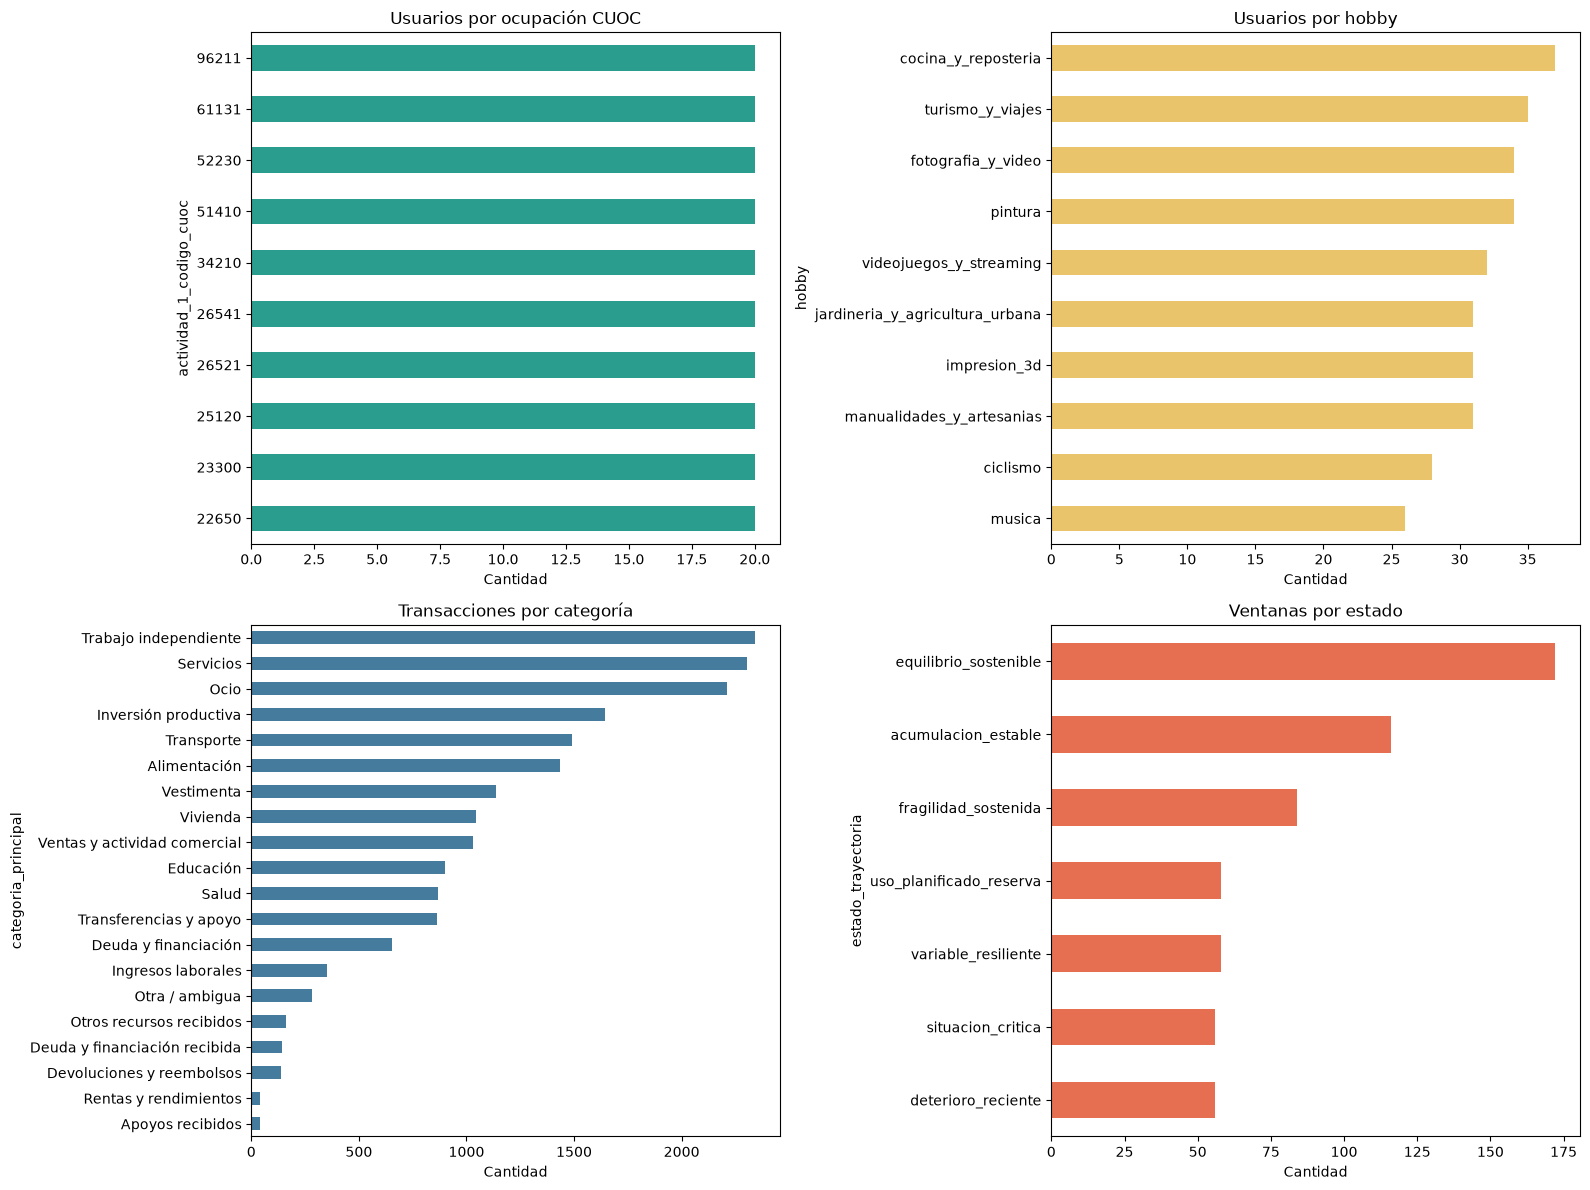

In [77]:
#Distribuciones
fig, ejes = plt.subplots(2, 2, figsize=(16, 12))
ocupaciones.set_index('actividad_1_codigo_cuoc')['usuarios'].sort_values().plot.barh(ax=ejes[0, 0], color='#2A9D8F', title='Usuarios por ocupación CUOC')
conteo_hobbies.set_index('hobby')['usuarios'].sort_values().plot.barh(ax=ejes[0, 1], color='#E9C46A', title='Usuarios por hobby')
transacciones['categoria_principal'].value_counts().sort_values().plot.barh(ax=ejes[1, 0], color='#457B9D', title='Transacciones por categoría')
trayectorias['estado_trayectoria'].value_counts().sort_values().plot.barh(ax=ejes[1, 1], color='#E76F51', title='Ventanas por estado')

for eje in ejes.flat:
    eje.set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

## 11. Contrafactuales contextuales

La misma descripción debe poder recibir una interpretación laboral o de hobby cuando la nota y el perfil aportan contextos diferentes.


In [78]:
#Contrastes
contrastes = transacciones.groupby('descripcion_normalizada').agg(
    categorias=('categoria_principal', 'nunique'),
    finalidades=('finalidad', 'nunique'),
    perfiles=('perfil_id', 'nunique'),
).reset_index()

contrastes = contrastes.loc[contrastes['categorias'].gt(1) | contrastes['finalidades'].gt(1)].sort_values(['categorias', 'perfiles'], ascending=False)
display(contrastes.reset_index(drop=True))

,descripcion_normalizada,categorias,finalidades,perfiles
0,transferencia ayuda,2,2,94
1,mantenimiento bicicleta,2,2,35
2,filamento impresion 3d,2,2,33
3,accesorio camara,2,2,30
4,accesorios bicicleta,2,2,29
5,repuesto impresora 3d,2,2,27
6,compra computador,2,2,23
7,compra tarjeta grafica,2,2,22
8,compra camara,2,2,20
9,compra audifonos,2,2,19


In [79]:
#Objetos contextuales
objetos_contextuales = [
    'compra audifonos',
    'compra camara',
    'compra tarjeta grafica',
    'compra computador',
    'filamento impresion 3d',
    'repuesto impresora 3d',
    'accesorio camara',
    'mantenimiento bicicleta',
    'accesorios bicicleta',
]

revision_contextual = []

for descripcion in objetos_contextuales:
    grupo = transacciones.loc[transacciones['descripcion_normalizada'].eq(descripcion)]
    categorias = set(grupo['categoria_principal'])
    finalidades = set(grupo['finalidad'])
    particiones_completas = all(
        {'Ocio', 'Inversión productiva'}.issubset(set(grupo.loc[grupo['particion'].eq(particion), 'categoria_principal']))
        for particion in orden_particiones
    )
    notas_completas = bool(grupo['nota_usuario'].fillna('').astype(str).str.strip().ne('').all())
    revision_contextual.append({
        'descripcion': descripcion,
        'registros': len(grupo),
        'ocio': int(grupo['categoria_principal'].eq('Ocio').sum()),
        'inversion_productiva': int(grupo['categoria_principal'].eq('Inversión productiva').sum()),
        'finalidades_completas': {'hobby', 'laboral'}.issubset(finalidades),
        'tres_particiones_completas': particiones_completas,
        'notas_completas': notas_completas,
    })

revision_contextual = pd.DataFrame(revision_contextual)
columnas_contexto_ok = ['finalidades_completas', 'tres_particiones_completas', 'notas_completas']
contrafactuales_ok = bool(revision_contextual[columnas_contexto_ok].all().all())
display(revision_contextual)
assert contrafactuales_ok, 'Los contrafactuales no cubren ambos contextos en las tres particiones'

,descripcion,registros,ocio,inversion_productiva,finalidades_completas,tres_particiones_completas,notas_completas
0,compra audifonos,24,12,12,True,True,True
1,compra camara,24,12,12,True,True,True
2,compra tarjeta grafica,24,12,12,True,True,True
3,compra computador,24,12,12,True,True,True
4,filamento impresion 3d,62,50,12,True,True,True
5,repuesto impresora 3d,43,31,12,True,True,True
6,accesorio camara,48,36,12,True,True,True
7,mantenimiento bicicleta,57,12,45,True,True,True
8,accesorios bicicleta,52,40,12,True,True,True


In [80]:
#Pares contextuales
muestra_contextual = transacciones.loc[transacciones['descripcion_normalizada'].isin(objetos_contextuales)].sort_values(['descripcion_normalizada', 'categoria_principal', 'perfil_id'])
muestra_contextual = muestra_contextual.groupby(['descripcion_normalizada', 'categoria_principal'], as_index=False).head(1)
contexto_perfil = perfiles[['perfil_id', 'actividad_1_familia', 'actividad_2_familia', 'hobby_1', 'hobby_2']]
muestra_contextual = muestra_contextual.merge(contexto_perfil, on='perfil_id', how='left')

display(muestra_contextual[[
    'descripcion_original', 'categoria_principal', 'finalidad', 'nota_usuario',
    'actividad_1_familia', 'actividad_2_familia', 'hobby_1', 'hobby_2', 'particion',
]].reset_index(drop=True))

,descripcion_original,categoria_principal,finalidad,nota_usuario,actividad_1_familia,actividad_2_familia,hobby_1,hobby_2,particion
0,ACCESORIO CAMARA,Inversión productiva,laboral,El accesorio de cámara es para producir contenido de mi actividad diseno_audiovisual_y_edicion_de_video.,musica_y_entretenimiento_dj,diseno_audiovisual_y_edicion_de_video,manualidades_y_artesanias,impresion_3d,train
1,ACCESORIO CAMARA,Ocio,hobby,El accesorio de cámara es para fotografía y video como hobby.,nutricion_y_dietetica,NaN,cocina_y_reposteria,fotografia_y_video,train
2,ACCESORIOS BICICLETA,Inversión productiva,laboral,Los accesorios son para una bicicleta utilizada en mi actividad domicilios_mensajeria_y_reparto.,domicilios_mensajeria_y_reparto,ventas_al_por_menor,fotografia_y_video,ciclismo,train
3,ACCESORIOS BICICLETA,Ocio,hobby,Los accesorios son para la bicicleta que uso como hobby.,peluqueria_y_barberia,NaN,ciclismo,NaN,train
4,COMPRA AUDIFONOS,Inversión productiva,laboral,Los audífonos son para presentaciones y mezcla de audio de mi actividad musica_y_entretenimiento_dj.,musica_y_entretenimiento_dj,NaN,manualidades_y_artesanias,NaN,train
5,COMPRA AUDIFONOS,Ocio,hobby,Los audífonos son para escuchar música en mi tiempo libre.,deporte_competitivo_ciclismo,NaN,musica,NaN,train
6,COMPRA CAMARA,Inversión productiva,laboral,La cámara es para producir contenido de mi actividad diseno_audiovisual_y_edicion_de_video.,diseno_audiovisual_y_edicion_de_video,NaN,turismo_y_viajes,ciclismo,train
7,COMPRA CAMARA,Ocio,hobby,La cámara es para practicar fotografía y video como hobby.,domicilios_mensajeria_y_reparto,ventas_al_por_menor,fotografia_y_video,ciclismo,train
8,COMPRA COMPUTADOR,Inversión productiva,laboral,El computador es una herramienta confirmada para mi actividad diseno_audiovisual_y_edicion_de_video.,diseno_audiovisual_y_edicion_de_video,NaN,turismo_y_viajes,ciclismo,train
9,COMPRA COMPUTADOR,Ocio,hobby,El computador es para videojuegos y streaming en mi tiempo libre.,ventas_al_por_menor,NaN,videojuegos_y_streaming,NaN,test


## 12. Reconciliación de trayectorias

Los agregados principales de cada ventana se recalculan desde las transacciones correspondientes al mismo perfil y periodo.


In [81]:
#Recalcular ventanas
transacciones_calculo = transacciones.copy()
transacciones_calculo['fecha_calculo'] = pd.to_datetime(transacciones_calculo['fecha'], errors='coerce')
transacciones_calculo['valor_calculo'] = pd.to_numeric(transacciones_calculo['valor'], errors='coerce')
trayectorias_calculo = trayectorias.copy()
trayectorias_calculo['desde_calculo'] = pd.to_datetime(trayectorias_calculo['periodo_desde'], errors='coerce')
trayectorias_calculo['hasta_calculo'] = pd.to_datetime(trayectorias_calculo['periodo_hasta'], errors='coerce')
errores_ventanas = []

for _, ventana in trayectorias_calculo.iterrows():
    grupo = transacciones_calculo.loc[
        transacciones_calculo['perfil_id'].eq(ventana['perfil_id'])
        & transacciones_calculo['fecha_calculo'].between(ventana['desde_calculo'], ventana['hasta_calculo'])
    ]
    sumar = lambda condicion: float(grupo.loc[condicion, 'valor_calculo'].sum())
    calculados = {
        'transacciones_observadas': float(len(grupo)),
        'ingresos_generados': sumar(grupo['tipo_movimiento'].eq('ingreso_generado')),
        'apoyos_recibidos': sumar(grupo['tipo_movimiento'].eq('apoyo_recibido')),
        'prestamos_recibidos': sumar(grupo['tipo_movimiento'].eq('financiacion_recibida')),
        'devoluciones_y_reembolsos': sumar(grupo['tipo_movimiento'].eq('devolucion')),
        'otros_recursos_recibidos': sumar(grupo['tipo_movimiento'].eq('otro_recurso')),
        'gastos_totales': sumar(grupo['tipo_movimiento'].isin(['gasto', 'pago_deuda', 'transferencia_apoyo']) & grupo['direccion'].eq('salida')),
        'gastos_hobbies': sumar(grupo['finalidad'].eq('hobby')),
        'inversion_productiva': sumar(grupo['categoria_principal'].eq('Inversión productiva')),
        'pagos_deuda': sumar(grupo['tipo_movimiento'].eq('pago_deuda')),
    }
    
    diferencias = [
        campo for campo, valor in calculados.items()
        if not np.isclose(float(ventana[campo]), valor, atol=0.01)
    ]
    
    if diferencias:
        errores_ventanas.append({'ventana_id': ventana['ventana_id'], 'campos_diferentes': ' | '.join(diferencias)})

errores_ventanas = pd.DataFrame(errores_ventanas)
display(errores_ventanas if not errores_ventanas.empty else pd.DataFrame([{'resultado': 'Las 600 ventanas coinciden con las transacciones'}]))

,resultado
0,Las 600 ventanas coinciden con las transacciones


In [82]:
#Validar ventanas
ventanas_por_perfil = trayectorias.groupby('perfil_id')['ventana_id'].count()

revision_ventanas = pd.DataFrame([
    {'control': 'tres ventanas por perfil', 'errores': int(ventanas_por_perfil.ne(3).sum())},
    {'control': 'agregados reconciliados', 'errores': int(len(errores_ventanas))},
    {'control': 'periodos válidos', 'errores': int((pd.to_datetime(trayectorias['periodo_desde']) > pd.to_datetime(trayectorias['periodo_hasta'])).sum())},
])

trayectorias_ok = bool(revision_ventanas['errores'].eq(0).all())
display(revision_ventanas)
assert trayectorias_ok, 'Las trayectorias no se pueden reproducir desde las transacciones'

,control,errores
0,tres ventanas por perfil,0
1,agregados reconciliados,0
2,periodos válidos,0


## 13. Contrato para evitar fuga de información

Las columnas objetivo y los metadatos de generación pueden utilizarse para evaluar, pero nunca como variables de entrada del modelo.


In [83]:
#Definir contrato de perfil
entrada_usuario = ['descripcion_visible']

objetivos_usuario = [
    'actividad_1_familia', 'actividad_1_codigo_cuoc', 'actividad_1_ocupacion_cuoc',
    'actividad_1_denominacion_cuoc', 'hobby_1', 'hobby_2', 'meta_declarada',
]

prohibidas_usuario = [
    'perfil_id', 'particion', 'realidad_sintetica_completa', 'informacion_extraible',
    'informacion_no_determinable', 'historia_financiera_controlada', 'liquidez_inicial',
    'deuda_inicial', 'es_sintetico', 'version_esquema', 'huella_registro',
]

contrato_usuario = pd.DataFrame([
    {'grupo': 'entrada', 'columnas': ' | '.join(entrada_usuario)},
    {'grupo': 'objetivos', 'columnas': ' | '.join(objetivos_usuario)},
    {'grupo': 'prohibidas como entrada', 'columnas': ' | '.join(prohibidas_usuario)},
])

display(contrato_usuario)

,grupo,columnas
0,entrada,descripcion_visible
1,objetivos,actividad_1_familia | actividad_1_codigo_cuoc | actividad_1_ocupacion_cuoc | actividad_1_denominacion_cuoc | hobby_1...
2,prohibidas como entrada,perfil_id | particion | realidad_sintetica_completa | informacion_extraible | informacion_no_determinable | historia...


In [84]:
#Definir contrato de transacciones
entrada_transaccion = [
    'descripcion_original', 'valor', 'direccion', 'tipo_movimiento', 'nota_usuario',
]

objetivos_transaccion = [
    'categoria_principal', 'subcategoria', 'finalidad', 'esencialidad', 'estado_clasificacion',
]

prohibidas_transaccion = [
    'transaccion_id', 'perfil_id', 'particion', 'relacion_actividad', 'relacion_hobby',
    'evidencia_contextual', 'confianza_objetivo', 'etiqueta_revisada',
    'historia_financiera_controlada', 'es_sintetico', 'version_taxonomia',
    'version_esquema', 'huella_registro',
]

contrato_transaccion = pd.DataFrame([
    {'grupo': 'entrada base', 'columnas': ' | '.join(entrada_transaccion)},
    {'grupo': 'objetivos', 'columnas': ' | '.join(objetivos_transaccion)},
    {'grupo': 'prohibidas como entrada', 'columnas': ' | '.join(prohibidas_transaccion)},
])

display(contrato_transaccion)

,grupo,columnas
0,entrada base,descripcion_original | valor | direccion | tipo_movimiento | nota_usuario
1,objetivos,categoria_principal | subcategoria | finalidad | esencialidad | estado_clasificacion
2,prohibidas como entrada,transaccion_id | perfil_id | particion | relacion_actividad | relacion_hobby | evidencia_contextual | confianza_obje...


## 14. Resultado de la auditoría

El notebook termina con una única tabla de aceptación. Cualquier bloqueo impide continuar con el entrenamiento.


In [85]:
#Resumen
controles_finales = pd.DataFrame([
    {'control': 'archivos obligatorios', 'cumple': archivos_ok},
    {'control': 'cantidades esperadas', 'cumple': filas_ok},
    {'control': 'esquemas obligatorios', 'cumple': esquema_ok},
    {'control': 'diez ocupaciones balanceadas', 'cumple': ocupaciones_ok},
    {'control': 'diez hobbies', 'cumple': hobbies_ok},
    {'control': 'alcance cerrado', 'cumple': alcance_ok},
    {'control': 'estratificación 14/3/3', 'cumple': estratificacion_ok},
    {'control': 'particiones separadas', 'cumple': separacion_ok},
    {'control': 'calidad básica', 'cumple': calidad_ok},
    {'control': 'sin duplicados', 'cumple': duplicados_ok},
    {'control': 'huellas correctas', 'cumple': huellas_ok},
    {'control': 'relaciones entre datasets', 'cumple': relaciones_ok},
    {'control': 'contrafactuales contextuales', 'cumple': contrafactuales_ok},
    {'control': 'trayectorias reproducibles', 'cumple': trayectorias_ok},
])

controles_finales['estado'] = np.where(controles_finales['cumple'], 'OK', 'BLOQUEO')
auditoria_ok = bool(controles_finales['cumple'].all())
display(controles_finales)
assert auditoria_ok, 'La auditoría detectó uno o más bloqueos'
print('Auditoría finalizada de forma exitosa')

,control,cumple,estado
0,archivos obligatorios,True,OK
1,cantidades esperadas,True,OK
2,esquemas obligatorios,True,OK
3,diez ocupaciones balanceadas,True,OK
4,diez hobbies,True,OK
5,alcance cerrado,True,OK
6,estratificación 14/3/3,True,OK
7,particiones separadas,True,OK
8,calidad básica,True,OK
9,sin duplicados,True,OK


AUDITORÍA COMPLETA: datasets v1.1 listos para los notebooks siguientes
